# Scenario 3 analysis — local/JGEA output
Notebook này đọc output JGEA của bạn (`scenario3-progress.csv` hoặc `scenario3-progress.(1).csv`) và chuẩn hóa tên cột để phân tích Scenario 3.


In [6]:
import os, glob, math, statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# Chọn file progress CSV. Ưu tiên file trong cùng thư mục notebook.
candidates = [
    'scenario3-progress.csv',
    'scenario3-progress.(1).csv',
    'Scenario_3.csv',
]
file_name = next((f for f in candidates if os.path.exists(f)), None)
if file_name is None:
    found = glob.glob('*.csv')
    raise FileNotFoundError(f'Không thấy file progress CSV. CSV tìm được: {found}')

separator = ';'
experiment_name = 'Scenario_3'
delta_quantization = 100
level_significance = 0.01
efficiency_percentile_reference = 0.75

os.makedirs(f'Figures/{experiment_name}', exist_ok=True)
os.makedirs(f'LaTeX/{experiment_name}', exist_ok=True)
os.makedirs(f'XLSX Files/{experiment_name}', exist_ok=True)

print('Reading:', file_name)
fileCSV = pd.read_csv(file_name, sep=separator)
print(fileCSV.shape)
fileCSV.head()


Reading: Scenario_3.csv
(829080, 15)


,seed,problem,solver_sigma,iterations,evals,births,elapsed.seconds,all→size,firsts→size,lasts→size,all→each[genotype]→uniqueness,all→each[solution]→uniqueness,all→each[fitness]→uniqueness,best→genotype→size,best→control.quality
0,5,small_barrier-3,cmaEs,1,18,18,0.271,18,1,1,1.0,1.0,1.0,122,0.235803
1,1,small_barrier-3,cmaEs,1,18,18,0.288,18,1,1,1.0,1.0,1.0,122,0.554990
2,3,small_barrier-3,cmaEs,1,18,18,0.248,18,1,1,1.0,1.0,1.0,122,0.246439
3,7,small_barrier-3,cmaEs,1,18,18,0.321,18,1,1,1.0,1.0,1.0,122,0.238485
4,9,small_barrier-3,cmaEs,1,18,18,0.323,18,1,1,1.0,1.0,1.0,122,0.385851


In [7]:
# Chuẩn hóa tên cột từ output JGEA hiện tại sang tên notebook cần dùng
rename_map = {
    'n.iterations': 'iterations',
    'n.evals': 'evals',
    'n.births': 'births',
    'elapsed.secs': 'elapsed.seconds',
    'best→quality→behavior.quality→avg.dist': 'best_fitness',
    'best→control.quality': 'best_fitness',
    'best→genotype→size': 'genotype_size',
}
fileCSV = fileCSV.rename(columns={k:v for k,v in rename_map.items() if k in fileCSV.columns})

required = ['seed','problem','solver_sigma','iterations','evals','births','elapsed.seconds','genotype_size','best_fitness']
missing = [c for c in required if c not in fileCSV.columns]
if missing:
    raise ValueError(f'Thiếu cột bắt buộc: {missing}. Cột hiện có: {list(fileCSV.columns)}')

# Solver/sigma: chỉ tách sigma cho ES-* và GA-*; không tách CMA-ES thành CMA + ES
fileCSV['solver'] = np.where(fileCSV['solver_sigma'].str.startswith('ES-'), 'ES',
                      np.where(fileCSV['solver_sigma'].str.startswith('GA-'), 'GA', fileCSV['solver_sigma']))
fileCSV['sigma'] = np.where(fileCSV['solver_sigma'].str.startswith('ES-') | fileCSV['solver_sigma'].str.startswith('GA-'),
                     fileCSV['solver_sigma'].str.split('-', n=1).str[1], fileCSV['solver_sigma'])
fileCSV['solver_sigma_seed'] = fileCSV['solver_sigma'] + '_seed:' + fileCSV['seed'].astype(str)
fileCSV['objective'] = 'minimize'
fileCSV['evals_quantized'] = fileCSV['evals'].astype(int) // delta_quantization

united_CSV = fileCSV.copy()
print('Rows:', len(united_CSV))
print('Problems:', united_CSV['problem'].nunique(), sorted(united_CSV['problem'].unique()))
print('Solvers:', united_CSV['solver_sigma'].nunique(), sorted(united_CSV['solver_sigma'].unique()))
print('Seeds:', united_CSV['seed'].nunique(), sorted(united_CSV['seed'].unique())[:5], '...', sorted(united_CSV['seed'].unique())[-5:])
print('Unique runs:', united_CSV.groupby(['problem','solver_sigma','seed']).ngroups)
united_CSV.head()


Rows: 829080
Problems: 9 ['easy_maze-3', 'easy_maze-5', 'easy_maze-9', 'large_barrier-3', 'large_barrier-5', 'large_barrier-9', 'small_barrier-3', 'small_barrier-5', 'small_barrier-9']
Solvers: 9 ['cmaEs', 'de', 'ga-0.02', 'ga-0.25', 'ga-0.5', 'pso', 'simpleEs-0.02', 'simpleEs-0.25', 'simpleEs-0.5']
Seeds: 30 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] ... [np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Unique runs: 2430


,seed,problem,solver_sigma,iterations,evals,births,elapsed.seconds,all→size,firsts→size,lasts→size,all→each[genotype]→uniqueness,all→each[solution]→uniqueness,all→each[fitness]→uniqueness,genotype_size,best_fitness,solver,sigma,solver_sigma_seed,objective,evals_quantized
0,5,small_barrier-3,cmaEs,1,18,18,0.271,18,1,1,1.0,1.0,1.0,122,0.235803,cmaEs,cmaEs,cmaEs_seed:5,minimize,0
1,1,small_barrier-3,cmaEs,1,18,18,0.288,18,1,1,1.0,1.0,1.0,122,0.554990,cmaEs,cmaEs,cmaEs_seed:1,minimize,0
2,3,small_barrier-3,cmaEs,1,18,18,0.248,18,1,1,1.0,1.0,1.0,122,0.246439,cmaEs,cmaEs,cmaEs_seed:3,minimize,0
3,7,small_barrier-3,cmaEs,1,18,18,0.321,18,1,1,1.0,1.0,1.0,122,0.238485,cmaEs,cmaEs,cmaEs_seed:7,minimize,0
4,9,small_barrier-3,cmaEs,1,18,18,0.323,18,1,1,1.0,1.0,1.0,122,0.385851,cmaEs,cmaEs,cmaEs_seed:9,minimize,0


In [8]:
# Lấy dòng cuối của mỗi run: dùng cho effectiveness/NOVS/NER
last_evals_df = united_CSV.loc[united_CSV.groupby(['problem','solver_sigma','seed'])['evals'].idxmax()].copy()
print(last_evals_df.shape)
print('Expected final rows for full Scenario 3:', 9*9*30)
last_evals_df.head()


(2430, 20)
Expected final rows for full Scenario 3: 2430


,seed,problem,solver_sigma,iterations,evals,births,elapsed.seconds,all→size,firsts→size,lasts→size,all→each[genotype]→uniqueness,all→each[solution]→uniqueness,all→each[fitness]→uniqueness,genotype_size,best_fitness,solver,sigma,solver_sigma_seed,objective,evals_quantized
96064,1,easy_maze-3,cmaEs,556,10008,10008,123.366,18,1,1,1.0,1.0,1.0,122,0.254897,cmaEs,cmaEs,cmaEs_seed:1,minimize,100
96107,2,easy_maze-3,cmaEs,556,10008,10008,123.070,18,1,1,1.0,1.0,1.0,122,0.416984,cmaEs,cmaEs,cmaEs_seed:2,minimize,100
96126,3,easy_maze-3,cmaEs,556,10008,10008,123.162,18,1,1,1.0,1.0,1.0,122,0.251126,cmaEs,cmaEs,cmaEs_seed:3,minimize,100
96205,4,easy_maze-3,cmaEs,556,10008,10008,123.074,18,1,1,1.0,1.0,1.0,122,0.258260,cmaEs,cmaEs,cmaEs_seed:4,minimize,100
96232,5,easy_maze-3,cmaEs,556,10008,10008,123.296,18,1,1,1.0,1.0,1.0,122,0.526097,cmaEs,cmaEs,cmaEs_seed:5,minimize,100


In [9]:
# Kiểm tra completeness
summary = {
    'progress_rows': len(united_CSV),
    'final_rows': len(last_evals_df),
    'n_problems': united_CSV['problem'].nunique(),
    'n_solvers': united_CSV['solver_sigma'].nunique(),
    'n_seeds': united_CSV['seed'].nunique(),
    'min_final_evals': int(last_evals_df['evals'].min()),
    'max_final_evals': int(last_evals_df['evals'].max()),
}
print(summary)
print('Genotype size by problem:')
print(last_evals_df.groupby('problem')['genotype_size'].unique())


{'progress_rows': 829080, 'final_rows': 2430, 'n_problems': 9, 'n_solvers': 9, 'n_seeds': 30, 'min_final_evals': 10000, 'max_final_evals': 10010}
Genotype size by problem:
problem
easy_maze-3        [122]
easy_maze-5        [212]
easy_maze-9        [464]
large_barrier-3    [122]
large_barrier-5    [212]
large_barrier-9    [464]
small_barrier-3    [122]
small_barrier-5    [212]
small_barrier-9    [464]
Name: genotype_size, dtype: object


Problems: ['small_barrier-3', 'small_barrier-5', 'small_barrier-9', 'large_barrier-3', 'large_barrier-5', 'large_barrier-9', 'easy_maze-3', 'easy_maze-5', 'easy_maze-9']
Solvers: ['cmaEs', 'de', 'pso', 'simpleEs-0.02', 'simpleEs-0.25', 'simpleEs-0.5', 'ga-0.02', 'ga-0.25', 'ga-0.5']


C:\Users\ACER\AppData\Local\Temp\ipykernel_20736\2137847069.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot(data_to_plot, vert=False, labels=labels_to_plot)
C:\Users\ACER\AppData\Local\Temp\ipykernel_20736\2137847069.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot(data_to_plot, vert=False, labels=labels_to_plot)
C:\Users\ACER\AppData\Local\Temp\ipykernel_20736\2137847069.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot(data_to_plot, vert=False, labels=labels_to_plot)
C:\Users\ACER\AppData\Local\Temp\ipykernel_20736\2137847069.py:63: MatplotlibDeprecationWarnin

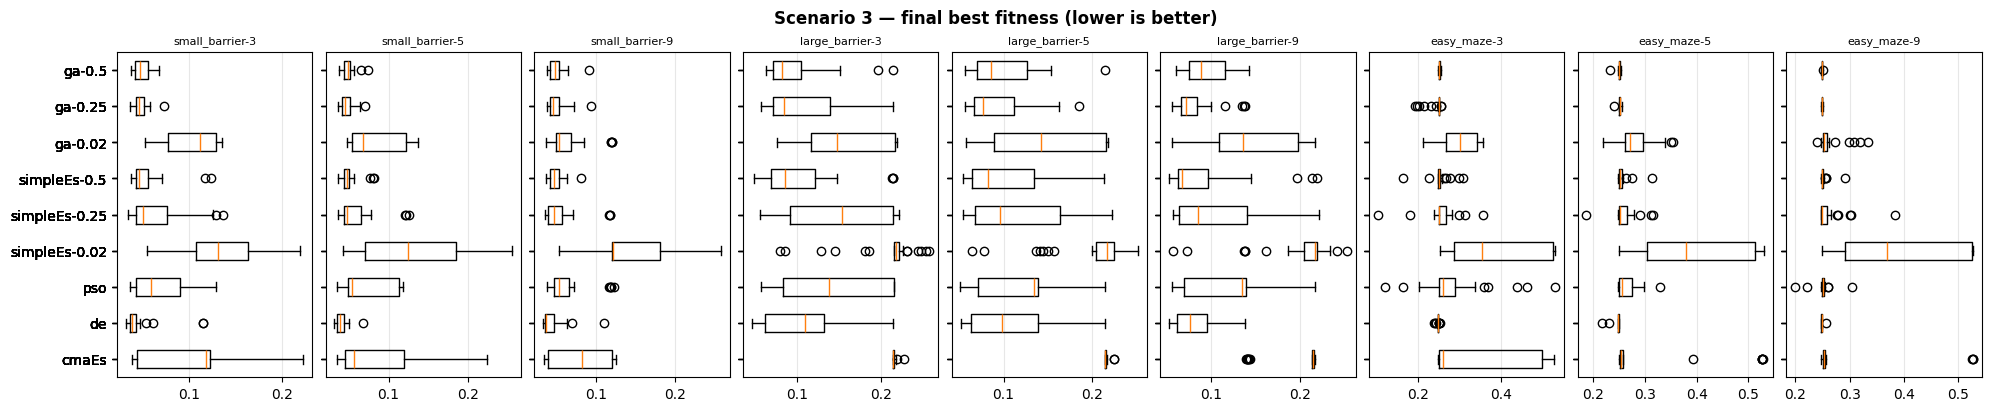

In [10]:
# Effectiveness boxplots giống Figure 7: final best fitness, càng nhỏ càng tốt

# Chuẩn hóa tên problem nếu còn [avg.dist]
united_CSV['problem'] = united_CSV['problem'].astype(str).str.replace(r'\[avg\.dist\]$', '', regex=True)
last_evals_df['problem'] = last_evals_df['problem'].astype(str).str.replace(r'\[avg\.dist\]$', '', regex=True)

# Thứ tự problem giống paper
problem_order = [
    'small_barrier-3', 'small_barrier-5', 'small_barrier-9',
    'large_barrier-3', 'large_barrier-5', 'large_barrier-9',
    'easy_maze-3', 'easy_maze-5', 'easy_maze-9'
]
problems = [p for p in problem_order if p in set(last_evals_df['problem'])]

# Thứ tự solver theo dataset mới của bạn
solver_order = [
    'cmaEs', 'de', 'pso',
    'simpleEs-0.02', 'simpleEs-0.25', 'simpleEs-0.5',
    'ga-0.02', 'ga-0.25', 'ga-0.5'
]
solvers_sigmas = [s for s in solver_order if s in set(last_evals_df['solver_sigma'])]

print("Problems:", problems)
print("Solvers:", solvers_sigmas)

if not problems:
    raise ValueError("Không tìm thấy problem nào khớp. Kiểm tra cột 'problem'.")
if not solvers_sigmas:
    raise ValueError("Không tìm thấy solver nào khớp. Kiểm tra cột 'solver_sigma'.")

fig, axs = plt.subplots(
    1, len(problems),
    sharex=False,
    sharey=True,
    layout='constrained',
    figsize=(2.2 * len(problems), 4)
)

if len(problems) == 1:
    axs = [axs]

fig.suptitle('Scenario 3 — final best fitness (lower is better)', fontsize=12, fontweight='bold')

for i, problem in enumerate(problems):
    data_to_plot = []
    labels_to_plot = []

    for s in solvers_sigmas:
        vals = last_evals_df[
            (last_evals_df['problem'] == problem) &
            (last_evals_df['solver_sigma'] == s)
        ]['best_fitness'].dropna().tolist()

        if len(vals) > 0:
            data_to_plot.append(vals)
            labels_to_plot.append(s)

    if len(data_to_plot) == 0:
        axs[i].set_title(problem + '\n(no data)', fontsize=8)
        axs[i].axis('off')
        continue

    axs[i].boxplot(data_to_plot, vert=False, labels=labels_to_plot)
    axs[i].set_title(problem, fontsize=8)
    axs[i].grid(True, axis='x', alpha=0.3)

plt.savefig(f'Figures/{experiment_name}/{experiment_name}_Effectiveness.png', bbox_inches='tight', dpi=300)
plt.show()

In [11]:
# NOVS: Number of Victories Score theo Wilcoxon, alpha=0.01
binary = pd.DataFrame(index=problems, columns=solvers_sigmas, dtype=float)
for problem in problems:
    filtered = last_evals_df[last_evals_df['problem']==problem]
    med = filtered.groupby('solver_sigma')['best_fitness'].median().sort_values(ascending=True)
    best_solver = med.index[0]
    best_vals = filtered[filtered['solver_sigma']==best_solver].sort_values('seed')['best_fitness'].to_numpy()
    for solver in solvers_sigmas:
        vals = filtered[filtered['solver_sigma']==solver].sort_values('seed')['best_fitness'].to_numpy()
        if solver == best_solver:
            binary.loc[problem, solver] = 1
        else:
            try:
                _, p_value = wilcoxon(best_vals, vals)
                binary.loc[problem, solver] = 1 if p_value > level_significance else 0
            except ValueError:
                binary.loc[problem, solver] = 1 if np.allclose(best_vals, vals) else 0
novs = binary.sum().sort_values(ascending=False)
print(novs)
binary.loc['NOVS'] = binary.sum()
binary.to_excel(f'XLSX Files/{experiment_name}/{experiment_name}_NOVS.xlsx')


de               9.0
ga-0.5           5.0
ga-0.25          4.0
simpleEs-0.5     3.0
simpleEs-0.25    3.0
pso              2.0
cmaEs            0.0
simpleEs-0.02    0.0
ga-0.02          0.0
dtype: float64


C:\Users\ACER\AppData\Local\Temp\ipykernel_20736\1334193686.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rankings[s] for s in solvers_sigmas], vert=False, labels=solvers_sigmas)


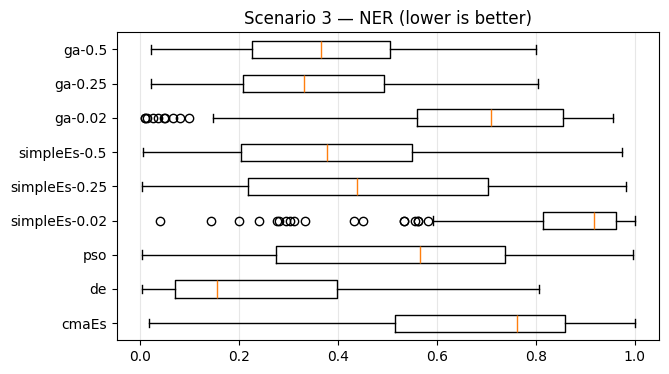

In [12]:
# NER: Normalized Effectiveness Rank
seeds = sorted(united_CSV['seed'].drop_duplicates().tolist())
solver_seed_keys = sorted(last_evals_df['solver_sigma_seed'].unique())
normalization_factor = len(solvers_sigmas) * len(seeds)
rankings = {s: [] for s in solvers_sigmas}
for problem in problems:
    sorted_data = last_evals_df[last_evals_df['problem']==problem].sort_values('best_fitness', ascending=True).reset_index(drop=True)
    for rank, row in sorted_data.iterrows():
        rankings[row['solver_sigma']].append((rank+1)/normalization_factor)
plt.figure(figsize=(7,4))
plt.boxplot([rankings[s] for s in solvers_sigmas], vert=False, labels=solvers_sigmas)
plt.title('Scenario 3 — NER (lower is better)')
plt.grid(True, axis='x', alpha=0.3)
plt.savefig(f'Figures/{experiment_name}/{experiment_name}_NER.png', bbox_inches='tight', dpi=300)
plt.show()


C:\Users\ACER\AppData\Local\Temp\ipykernel_20736\3292228697.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ettq[s] for s in solvers_sigmas], vert=False, labels=solvers_sigmas)


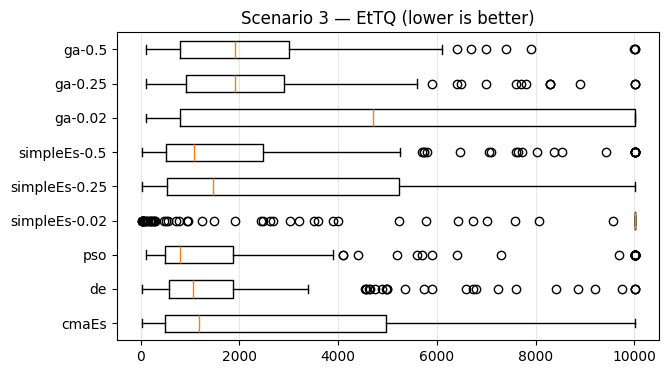

In [13]:
# EtTQ: evals to third quartile threshold
ettq = {s: [] for s in solvers_sigmas}
max_budget = int(united_CSV['evals'].max())
for problem in problems:
    final_problem = last_evals_df[last_evals_df['problem']==problem].sort_values('best_fitness', ascending=True).reset_index(drop=True)
    threshold_index = int(efficiency_percentile_reference * len(final_problem))
    threshold = final_problem.iloc[threshold_index]['best_fitness']
    for solver in solvers_sigmas:
        for seed in seeds:
            run = united_CSV[(united_CSV['problem']==problem) & (united_CSV['solver_sigma']==solver) & (united_CSV['seed']==seed)].sort_values('evals')
            hit = run[run['best_fitness'] <= threshold]
            ettq[solver].append(int(hit['evals'].iloc[0]) if not hit.empty else max_budget)
plt.figure(figsize=(7,4))
plt.boxplot([ettq[s] for s in solvers_sigmas], vert=False, labels=solvers_sigmas)
plt.title('Scenario 3 — EtTQ (lower is better)')
plt.grid(True, axis='x', alpha=0.3)
plt.savefig(f'Figures/{experiment_name}/{experiment_name}_EtTQ.png', bbox_inches='tight', dpi=300)
plt.show()
